# Generate example image montages from ALSF example plate

In [ ]:
import os
import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.image import imread
from pycytominer import annotate
from scipy.ndimage import binary_dilation

from cosmicqc import find_outliers


In [ ]:
def add_scale_bar(
    ax: plt.Axes, img_shape: tuple, bar_length_px: float, color: str = "white"
) -> None:
    """Draw a scale bar in the bottom-right corner of an imshow'd image.

    Args:
        ax (plt.Axes): The axes to draw the scale bar on.
        img_shape (tuple): The shape of the image (height, width).
        bar_length_px (float): The length of the scale bar in pixels.
        color (str): The color of the scale bar. Default is "white".
    """
    img_h, img_w = img_shape[0], img_shape[1]
    margin_x = img_w * 0.05
    margin_y = img_h * 0.05

    x_end = img_w - margin_x
    x_start = x_end - bar_length_px
    y_pos = img_h - margin_y

    ax.plot(
        [x_start, x_end],
        [y_pos, y_pos],
        color=color,
        linewidth=3,
        solid_capstyle="butt",
    )


def add_highlight_box(ax: plt.Axes, color: str = "red", linewidth: int = 4) -> None:
    """Draw a highlight box around the full axes (image) area.

    Args:
        ax (plt.Axes): The axes to draw the highlight box on.
        color (str): The color of the highlight box. Default is "red".
        linewidth (int): The width of the highlight box lines. Default is 4.
    """
    rect = mpatches.Rectangle(
        (0, 0),
        1,
        1,
        transform=ax.transAxes,
        fill=False,
        edgecolor=color,
        linewidth=linewidth,
        clip_on=False,
    )
    ax.add_patch(rect)


def overlay_outlines(
    ax: plt.Axes,
    plate: str,
    well: str,
    site: int,
    outlines_dir: Path,
    nuclei_color: tuple = (0, 255, 255),
    cell_color: tuple = (0, 255, 0),
    show_nuclei: bool = True,
    show_cells: bool = True,
    line_thickness: int = 1,
) -> None:
    """Overlay nuclei and cell segmentation outlines on an axes.

    Expects CellProfiler-style outline TIFFs named
    "NucleiOutlines_{plate}_{well}_{site}.tiff" and
    "CellsOutlines_{plate}_{well}_{site}.tiff" in outlines_dir, where outline
    pixels are non-zero in at least one channel and background pixels are zero.

    Args:
        ax (plt.Axes): The axes with the base image already drawn.
        plate (str): Plate identifier used in the outline filenames.
        well (str): Well identifier used in the outline filenames.
        site (int): Site/field number used in the outline filenames.
        outlines_dir (Path): Directory containing the outline TIFFs.
        nuclei_color (tuple): RGB (0-255) color for nuclei outlines. Default cyan.
        cell_color (tuple): RGB (0-255) color for cell outlines. Default green.
        show_nuclei (bool): Whether to draw nuclei outlines. Default True.
        show_cells (bool): Whether to draw cell outlines. Default True.
        line_thickness (int): Outline thickness in pixels, via binary dilation.
            Default 1 (no dilation).
    """
    overlays = []
    if show_nuclei:
        overlays.append(("NucleiOutlines", nuclei_color))
    if show_cells:
        overlays.append(("CellsOutlines", cell_color))

    for prefix, color in overlays:
        outline_path = outlines_dir / f"{prefix}_{plate}_{well}_{site}.tiff"
        if not outline_path.exists():
            continue
        outline = imread(outline_path)
        mask = outline.max(axis=-1) if outline.ndim == 3 else outline
        mask = mask > 0
        if line_thickness > 1:
            mask = binary_dilation(mask, iterations=line_thickness - 1)

        overlay = np.zeros((*mask.shape, 4))
        overlay[..., 0] = color[0] / 255
        overlay[..., 1] = color[1] / 255
        overlay[..., 2] = color[2] / 255
        overlay[..., 3] = mask.astype(float)
        ax.imshow(overlay)


In [14]:
# Set output directory for figures
output_dir = Path(
    "./figures"
)
output_dir.mkdir(parents=True, exist_ok=True)


# Set pixel size resolution for all plots
# Pixel size from Index.xml (ImageResolutionX/Y = 5.93376264949402E-07 m)
UM_PER_PIXEL = 0.593376264949402
SCALE_BAR_UM = 100
SCALE_BAR_PX = SCALE_BAR_UM / UM_PER_PIXEL  # ~168.5 px


# Blind the cell line names
cell_line_map = {
    "CHLA-10": "Cell line A",
    "CHLA-113": "Cell line B",
    "CHLA-218": "Cell line C",
    "CHLA-25": "Cell line D",
    "U2-OS": "Cell line E",
}

# set plate to analyze
plate_id = "BR00145816"

# directory containing per-FOV NucleiOutlines_*.tiff and CellsOutlines_*.tiff
# segmentation outline images produced during feature extraction
outlines_dir = Path(
    "/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/"
    "2.feature_extraction/sqlite_outputs/Round_2_data"
) / plate_id


In [15]:
# Load the data to generate the plots
example_df = pd.read_parquet(
    Path(
        f"/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/3.preprocessing_features/data/converted_profiles/Round_2_data/{plate_id}_converted.parquet"
    )
)

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_FileName_OrigDNA",
    "Image_FileName_OrigAGP",
    "Image_PathName_OrigDNA",
    "Image_PathName_OrigAGP",
    "Nuclei_AreaShape_BoundingBoxMaximum_X",
    "Nuclei_AreaShape_BoundingBoxMaximum_Y",
    "Nuclei_AreaShape_BoundingBoxMinimum_X",
    "Nuclei_AreaShape_BoundingBoxMinimum_Y",
    "Image_Metadata_Row",
    "Image_Metadata_Col",
    "Metadata_Nuclei_Number_Object_Number",
]

# Define the QC features
qc_features = [
    "Nuclei_Intensity_IntegratedIntensity_CorrDNA",
    "Nuclei_AreaShape_Solidity",
    "Nuclei_Intensity_MassDisplacement_CorrDNA",
    "Cells_Intensity_IntegratedIntensity_CorrDNA",
]

# Filter plate_df to only include metadata columns and QC features
filtered_plate_df = example_df[metadata_columns + qc_features]

print(example_df.shape)
example_df.head()


(78602, 3035)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Col,Image_Metadata_Plate,Image_Metadata_Row,Image_Metadata_Site,...,Nuclei_Texture_Variance_CorrER_3_02_256,Nuclei_Texture_Variance_CorrER_3_03_256,Nuclei_Texture_Variance_CorrMito_3_00_256,Nuclei_Texture_Variance_CorrMito_3_01_256,Nuclei_Texture_Variance_CorrMito_3_02_256,Nuclei_Texture_Variance_CorrMito_3_03_256,Nuclei_Texture_Variance_CorrRNA_3_00_256,Nuclei_Texture_Variance_CorrRNA_3_01_256,Nuclei_Texture_Variance_CorrRNA_3_02_256,Nuclei_Texture_Variance_CorrRNA_3_03_256
0,336.377009,104.297899,352.210413,116.052065,10,1,1,BR00145816,2,1,...,189.867760,175.258056,9.359696,9.455868,9.342000,8.864129,71.653567,78.652402,72.325106,67.668053
1,498.383356,81.555252,493.371429,74.367347,14,6,1,BR00145816,2,6,...,37.010230,42.539795,2.056842,2.040540,2.121985,2.797201,6.598058,6.854488,6.605123,6.568223
2,296.924490,42.889796,290.397623,54.289762,18,7,1,BR00145816,2,7,...,229.314572,218.190815,10.576748,10.938701,9.687250,8.795027,63.617244,65.864101,63.804281,64.184465
3,787.229535,286.391653,783.873688,289.240187,10,8,1,BR00145816,2,8,...,1496.307081,1538.527119,136.357027,127.891993,140.240277,141.944781,261.830682,243.596874,249.175994,255.187774
4,891.834437,104.026490,892.879444,102.732612,16,22,1,BR00145816,4,4,...,159.236979,153.487704,3.661602,3.331812,3.183244,3.233278,10.138008,9.798398,9.062918,8.676421


In [16]:
correct_parent = "/media/18tbdrive/ALSF_pilot_data"

for col in filtered_plate_df.columns:
    if "PathName" in col and "Illum" not in col:
        filtered_plate_df[col] = filtered_plate_df[col].apply(
            lambda x: (
                re.sub(r"^.*ALSF_pilot_data/", correct_parent + "/", x)
                if isinstance(x, str)
                else x
            )
        )

# Print example image path after fix
print(filtered_plate_df["Image_PathName_OrigDNA"].dropna().iloc[0])


/media/18tbdrive/ALSF_pilot_data/Round_2_data/Plate 4 All Cell Lines/BR00145816__2024-12-06T16_10_14-Measurement 1/Images


In [17]:
# Find large nuclei outliers for the current plate
nuclei_clustered_outliers = find_outliers(
    df=filtered_plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds={
        "Nuclei_Intensity_MassDisplacement_CorrDNA": 0.05,
        "Nuclei_Intensity_IntegratedIntensity_CorrDNA": 1.5,
    },
)

# Find low nuclei solidity outliers for the current plate
solidity_nuclei_outliers = find_outliers(
    df=filtered_plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds={
        # Set at this point where it looks like it starts to detect good quality nuclei
        "Nuclei_AreaShape_Solidity": -1.6,
    },
)

# Find cell outliers for the current plate
cell_outliers = find_outliers(
    df=filtered_plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds={
        # Set low to attempt to detect all instances of abnormally high int in nuclei for whole cells  # noqa: E501
        "Cells_Intensity_IntegratedIntensity_CorrDNA": 0.5,
    },
)


Number of outliers: 3630 (4.62%)
Outliers Range:
Nuclei_Intensity_MassDisplacement_CorrDNA Min: 0.5999707298906707
Nuclei_Intensity_MassDisplacement_CorrDNA Max: 14.840765847957671
Nuclei_Intensity_IntegratedIntensity_CorrDNA Min: 389.6632658392191
Nuclei_Intensity_IntegratedIntensity_CorrDNA Max: 1757.922207608819
Number of outliers: 5982 (7.61%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.6298932384341637
Nuclei_AreaShape_Solidity Max: 0.9082774049217002
Number of outliers: 7714 (9.81%)
Outliers Range:
Cells_Intensity_IntegratedIntensity_CorrDNA Min: 360.4617034448311
Cells_Intensity_IntegratedIntensity_CorrDNA Max: 11016.348135018721


In [18]:
# platemap file path
platemap_file = Path(
    "/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/0.download_data/metadata/platemaps/Assay_Plate4_platemap.csv"
)
platemap_df = pd.read_csv(platemap_file)

# Rename Image_Metadata_Site to Metadata_Site prior to annotation
filtered_plate_df = filtered_plate_df.rename(
    columns={"Image_Metadata_Site": "Metadata_Site"}
)

# Annotate the filtered_plate_df with metadata from platemap
annotated_plate_df = annotate(
    profiles=filtered_plate_df,
    platemap=platemap_df,
    join_on=["Metadata_well", "Image_Metadata_Well"],
)
print(annotated_plate_df.shape)
annotated_plate_df.head()


(75395, 25)


,Metadata_cell_line,Metadata_row,Metadata_column,Metadata_seeding_density,Metadata_condition,Metadata_Plate,Metadata_Well,Metadata_Site,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,...,Nuclei_AreaShape_BoundingBoxMaximum_X,Nuclei_AreaShape_BoundingBoxMaximum_Y,Nuclei_AreaShape_BoundingBoxMinimum_X,Nuclei_AreaShape_BoundingBoxMinimum_Y,Image_Metadata_Row,Image_Metadata_Col,Nuclei_Intensity_IntegratedIntensity_CorrDNA,Nuclei_AreaShape_Solidity,Nuclei_Intensity_MassDisplacement_CorrDNA,Cells_Intensity_IntegratedIntensity_CorrDNA
0,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,2,246.203991,172.938359,...,272.0,199.0,220.0,144.0,2,3,765.939727,0.981288,1.468688,788.089049
1,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,3,967.537313,10.373134,...,974.0,18.0,962.0,2.0,2,3,11.852596,0.937063,0.210698,12.318306
2,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,4,790.728831,265.952621,...,809.0,285.0,774.0,248.0,2,3,327.168328,0.963107,1.584961,342.412609
3,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,5,325.456089,68.548595,...,350.0,93.0,302.0,45.0,2,3,503.389291,0.976558,0.462842,540.055422
4,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,7,943.873239,113.425352,...,959.0,122.0,930.0,105.0,2,3,32.914259,0.951743,0.535042,43.821652


In [19]:
all_outlier_keys = set(
    pd.concat([nuclei_clustered_outliers, solidity_nuclei_outliers, cell_outliers])[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Metadata_Nuclei_Number_Object_Number",
        ]
    ].apply(tuple, axis=1)
)

# Rename well and plate to just Metadata_ prefix
all_outlier_keys = {
    (plate, well, site, int(obj_num))
    for (plate, well, site, obj_num) in all_outlier_keys
}


# Create failed_qc column, default to False
annotated_plate_df["failed_qc"] = False
# Set to True where the cell matches the outlier dataframe
annotated_plate_df.loc[
    annotated_plate_df[
        [
            "Metadata_Plate",
            "Metadata_Well",
            "Metadata_Site",
            "Metadata_Nuclei_Number_Object_Number",
        ]
    ]
    .apply(tuple, axis=1)
    .isin(all_outlier_keys),
    "failed_qc",
] = True

# Check result
annotated_plate_df["failed_qc"].value_counts()


failed_qc
False    63297
True     12098
Name: count, dtype: int64

In [20]:
# Find FOVs with highest failure rate per cell line
fov_failure_rates = (
    annotated_plate_df.groupby(["Metadata_cell_line", "Metadata_Well", "Metadata_Site"])
    .agg(
        total_cells=("failed_qc", "count"),
        failed_cells=("failed_qc", "sum"),
        failure_rate=("failed_qc", "mean"),
    )
    .reset_index()
    .sort_values(["Metadata_cell_line", "failure_rate"], ascending=[True, False])
)

# Get top 2 FOVs per cell line
top_fovs = fov_failure_rates.groupby("Metadata_cell_line").head(2)

# Get file paths for these FOVs
fov_images = annotated_plate_df.merge(
    top_fovs[
        [
            "Metadata_cell_line",
            "Metadata_Well",
            "Metadata_Site",
            "failed_cells",
            "total_cells",
            "failure_rate",
        ]
    ],
    on=["Metadata_cell_line", "Metadata_Well", "Metadata_Site"],
)[
    [
        "Metadata_cell_line",
        "Metadata_Well",
        "Metadata_Site",
        "Metadata_seeding_density",
        "failed_cells",
        "total_cells",
        "failure_rate",
        "Image_PathName_OrigDNA",
        "Image_FileName_OrigDNA",
    ]
].drop_duplicates()

top_fovs


,Metadata_cell_line,Metadata_Well,Metadata_Site,total_cells,failed_cells,failure_rate
59,CHLA-10,C03,3,6,4,0.666667
58,CHLA-10,C03,2,18,11,0.611111
177,CHLA-113,F12,8,65,44,0.676923
174,CHLA-113,F12,2,43,29,0.674419
347,CHLA-218,I05,5,14,9,0.642857
275,CHLA-218,H03,8,2,1,0.500000
450,CHLA-25,E03,5,12,5,0.416667
482,CHLA-25,E08,2,53,17,0.320755
613,U2-OS,K03,8,37,8,0.216216
615,U2-OS,K04,1,36,7,0.194444


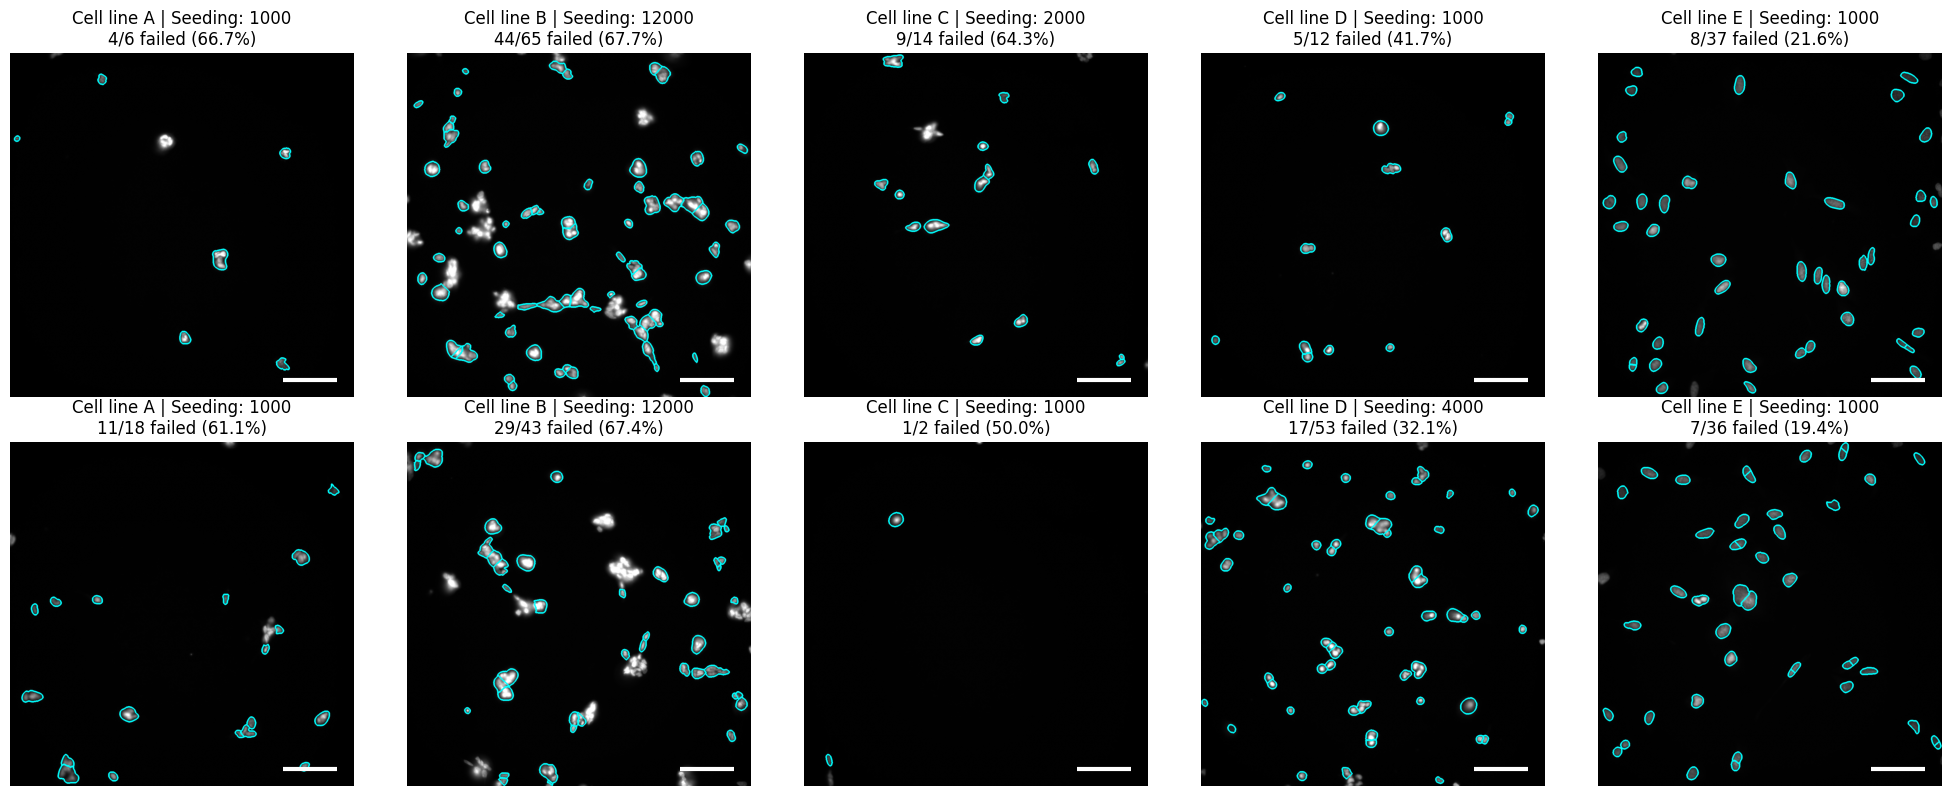

In [21]:
# Create a 2x5 subplot grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Get unique cell lines and sort them
cell_lines = sorted(fov_images["Metadata_cell_line"].unique())

# Iterate through each cell line and display the first two images
for col, cell_line in enumerate(cell_lines):
    cell_line_df = (
        fov_images[fov_images["Metadata_cell_line"] == cell_line]
        .sort_values("failure_rate", ascending=False)
        .reset_index(drop=True)
    )
    blinded_name = cell_line_map.get(cell_line, cell_line)
    for row in range(min(2, len(cell_line_df))):
        ax = axes[row * 5 + col]
        image_path = cell_line_df.loc[row, "Image_PathName_OrigDNA"]
        image_filename = cell_line_df.loc[row, "Image_FileName_OrigDNA"]
        full_path = os.path.join(image_path, image_filename)
        well = cell_line_df.loc[row, "Metadata_Well"]
        site = cell_line_df.loc[row, "Metadata_Site"]
        failed = cell_line_df.loc[row, "failed_cells"]
        total = cell_line_df.loc[row, "total_cells"]
        pct_failed = 100 * failed / total if total > 0 else 0
        try:
            img = imread(full_path)
            ax.imshow(img, cmap="gray")
            overlay_outlines(
                ax,
                plate_id,
                well,
                site,
                outlines_dir,
                show_cells=False,
                line_thickness=3,
            )
            add_scale_bar(ax, img.shape, SCALE_BAR_PX)
            seeding_density = cell_line_df.loc[row, "Metadata_seeding_density"]
            ax.set_title(
                (
                    f"{blinded_name} | Seeding: {seeding_density}\n"
                    f"{failed}/{total} failed ({pct_failed:.1f}%)"
                ),
                fontsize=12,
            )
            ax.axis("off")
        except Exception:
            ax.text(
                0.5,
                0.5,
                f"Error loading image\n{blinded_name}",
                ha="center",
                va="center",
                fontsize=12,
            )
            ax.axis("off")

# Hide unused subplots
for idx in range(2 * len(cell_lines), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(output_dir / "fov_images_by_cellline.png", dpi=150, bbox_inches="tight")
plt.show()


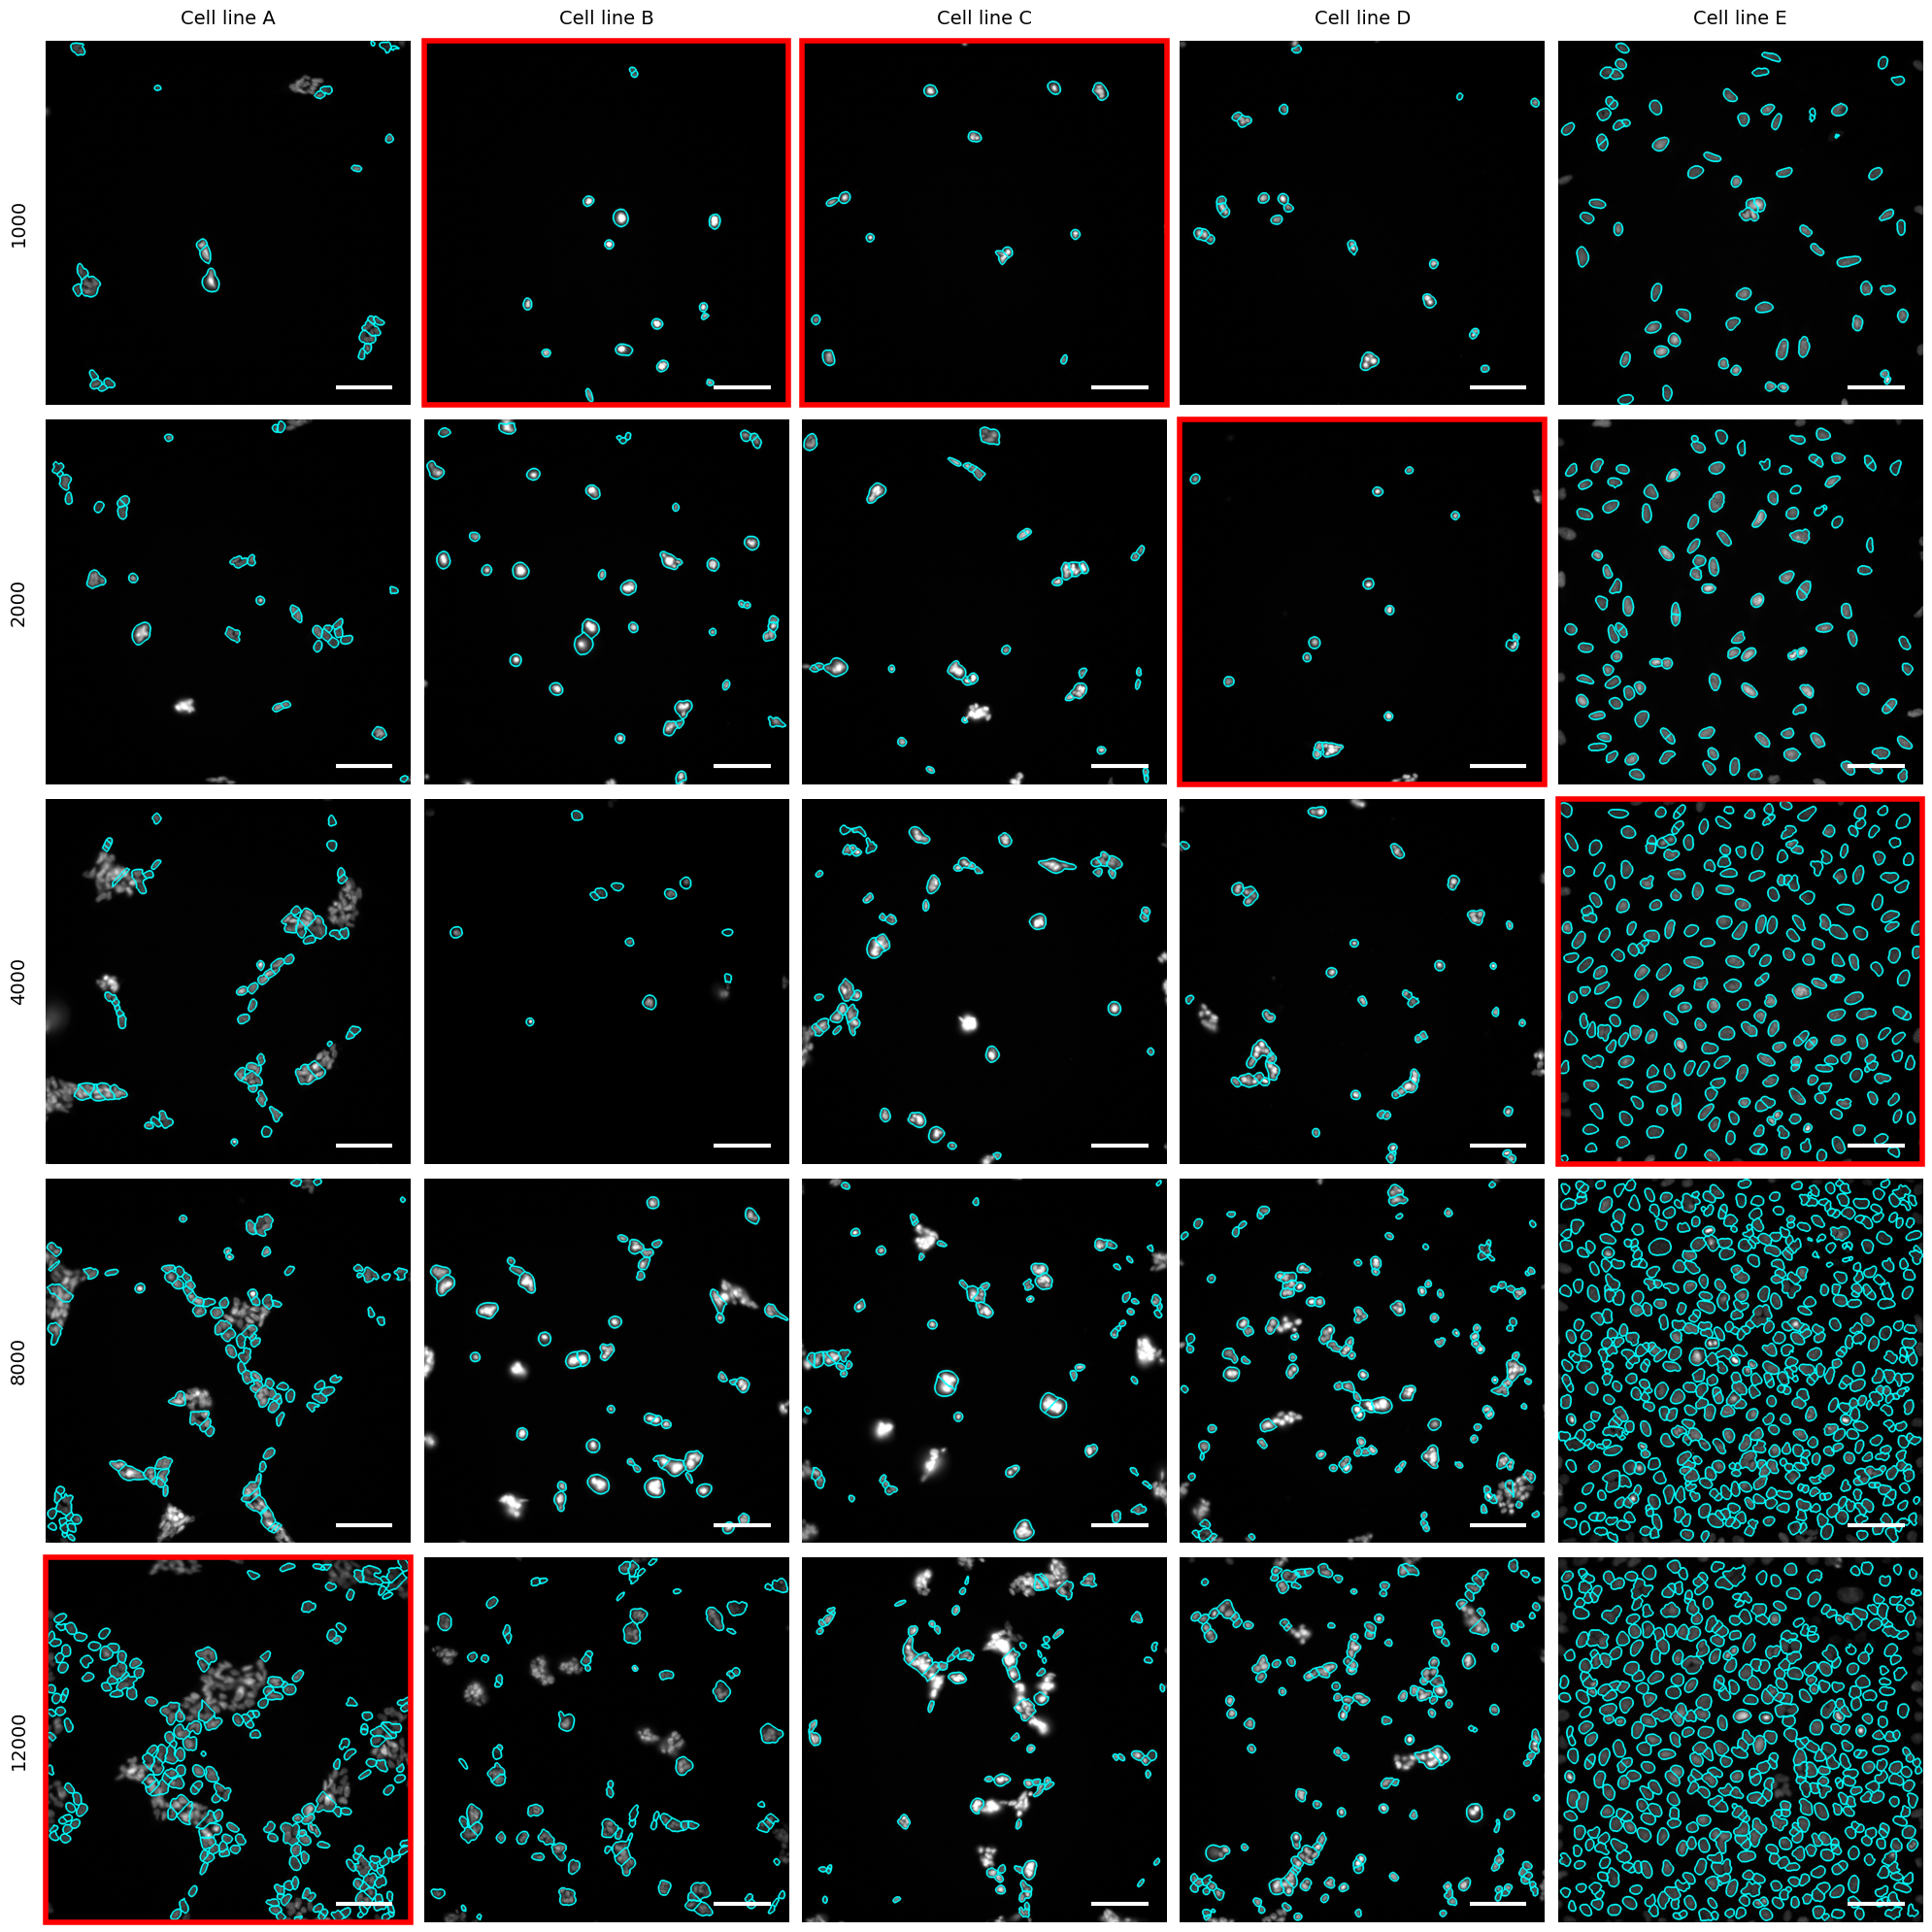

In [22]:
# "Most optimal" combos to highlight with a red box (blinded name -> seeding density)
# NOTE: adjust these density values/format (e.g. 12000 vs "12k") to match
# whatever format Metadata_seeding_density actually uses in your dataframe.
highlight_pairs = {
    "Cell line A": 12000,
    "Cell line B": 1000,
    "Cell line C": 1000,
    "Cell line D": 2000,
    "Cell line E": 4000,
}

cell_lines = sorted(annotated_plate_df["Metadata_cell_line"].unique())[:5]
seeding_densities = sorted(annotated_plate_df["Metadata_seeding_density"].unique())[:5]
random_state = 0
montage_records = []
for cell_line in cell_lines:
    for density in seeding_densities:
        subset = annotated_plate_df[
            (annotated_plate_df["Metadata_cell_line"] == cell_line)
            & (annotated_plate_df["Metadata_seeding_density"] == density)
        ]
        if subset.empty:
            continue
        montage_records.append(subset.sample(n=1, random_state=random_state))

montage_df = pd.concat(montage_records, ignore_index=True)
montage_index = montage_df.set_index(
    ["Metadata_cell_line", "Metadata_seeding_density"], drop=False
)

fig, axes = plt.subplots(
    len(seeding_densities),
    len(cell_lines),
    figsize=(20, 20),
    squeeze=False,
)

for row_idx, density in enumerate(seeding_densities):
    for col_idx, cell_line in enumerate(cell_lines):
        ax = axes[row_idx, col_idx]
        key = (cell_line, density)
        blinded_name = cell_line_map.get(cell_line, cell_line)
        if key not in montage_index.index:
            ax.axis("off")
            continue
        record = montage_index.loc[key]
        if isinstance(record, pd.DataFrame):
            record = record.iloc[0]
        full_path = os.path.join(
            record["Image_PathName_OrigDNA"], record["Image_FileName_OrigDNA"]
        )
        try:
            img = imread(full_path)
            ax.imshow(img, cmap="gray")
            overlay_outlines(
                ax,
                plate_id,
                record["Metadata_Well"],
                record["Metadata_Site"],
                outlines_dir,
                show_cells=False,
                line_thickness=3,
            )
            add_scale_bar(ax, img.shape, SCALE_BAR_PX)
        except Exception:
            ax.text(
                0.5,
                0.5,
                "Unable to load image",
                ha="center",
                va="center",
                fontsize=12,
            )
        ax.axis("off")
        if row_idx == 0:
            ax.set_title(blinded_name, fontsize=14, pad=12)
        if col_idx == 0:
            ax.set_ylabel(str(density), fontsize=14, rotation=90, labelpad=20, va="center")
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
        if highlight_pairs.get(blinded_name) == density:
            add_highlight_box(ax)

plt.tight_layout()
fig.savefig(output_dir / "random_fov_montage_5x5.png", dpi=150, bbox_inches="tight")
plt.show()
